# Step 2: Visual Math - Cost Function & Gradient Descent
# 第二步：图像数学 - 代价函数与梯度下降

> **No scary formulas! Only pictures and intuition.** 📊
> **没有可怕的公式！只有图像和直觉。** 📊

## 1. What is a Cost? / 什么是"代价"？

**English:** Imagine you are shooting arrows at a target. 🎯

- If you hit the center → **Low cost** (good!)
- If you miss by a lot → **High cost** (bad!)

**中文：** 想象你在射箭。🎯

- 射中靶心 → **代价低**（好！）
- 偏离很远 → **代价高**（不好！）

---

**English:** In machine learning:

- **Prediction = your arrow**
- **Real answer = the target center**
- **Cost = how far you missed**

**中文：** 在机器学习中：

- **预测 = 你的箭**
- **真实答案 = 靶心**
- **代价 = 你偏离了多少**

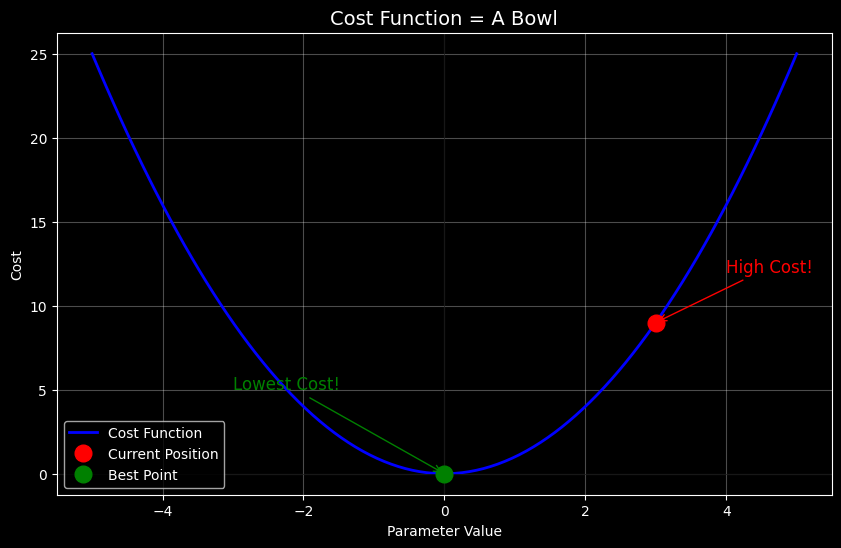

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Create a simple hill to represent cost / 创建一座简单的"山"代表代价
x = np.linspace(-5, 5, 100)
y = x**2  # A simple bowl shape / 一个简单的碗状

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Cost Function')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.axvline(x=0, color='k', linewidth=0.5)

# Mark a point far from bottom / 标记一个远离底部的点
plt.plot(3, 9, 'ro', markersize=12, label='Current Position')
plt.annotate('High Cost!', xy=(3, 9), xytext=(4, 12),
            fontsize=12, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

# Mark the bottom / 标记底部
plt.plot(0, 0, 'go', markersize=12, label='Best Point')
plt.annotate('Lowest Cost!', xy=(0, 0), xytext=(-3, 5),
            fontsize=12, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.title('Cost Function = A Bowl', fontsize=14)
plt.xlabel('Parameter Value')
plt.ylabel('Cost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 2. What is Gradient Descent? / 什么是梯度下降？

**English:** Imagine you are blindfolded on a mountain. 🏔️
You want to go to the **bottom** (lowest cost).

What do you do?

1. **Feel the ground** with your feet → Which way is down?
2. **Take one step** in that direction
3. **Repeat** until you reach the bottom

**中文：** 想象你被蒙着眼睛站在山上。🏔️
你想走到**山脚**（最低代价）。

你会怎么做？

1. **用脚感觉地面** → 哪边是下坡？
2. **朝那个方向走一步**
3. **重复**直到到达山脚

---

**English:** That is exactly what Gradient Descent does!

| Mountain / 山 | Machine Learning / 机器学习 |
|---------------|---------------------------|
| Your position / 你的位置 | Model parameters (w, b) / 模型参数 |
| Height / 高度 | Cost / 代价 |
| Feeling the slope / 感觉坡度 | Calculate gradient / 计算梯度 |
| Step size / 步长 | Learning rate / 学习率 |
| Bottom of mountain / 山脚 | Best model / 最佳模型 |

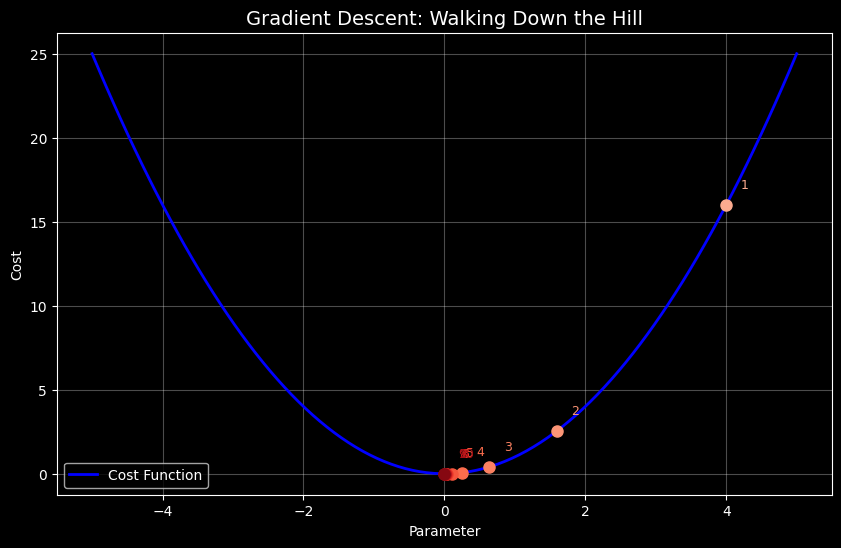

Steps taken: 10
Final position: 0.0004
Final cost: 0.0000


In [5]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5, 100)
y = x**2

# Simulate gradient descent steps / 模拟梯度下降步骤
learning_rate = 0.3
x_current = 4  # Start far from bottom / 从远离底部开始
steps = [x_current]

for i in range(10):
    gradient = 2 * x_current
    x_current = x_current - learning_rate * gradient
    steps.append(x_current)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='Cost Function')

# Plot each step / 画出每一步
for i, s in enumerate(steps):
    color = plt.cm.Reds(0.3 + 0.7 * i / len(steps))
    plt.plot(s, s**2, 'o', color=color, markersize=8)
    if i < len(steps) - 1:
        plt.annotate(f'{i+1}', xy=(s, s**2), xytext=(s+0.2, s**2+1),
                    fontsize=9, color=color)

plt.title('Gradient Descent: Walking Down the Hill', fontsize=14)
plt.xlabel('Parameter')
plt.ylabel('Cost')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Steps taken:", len(steps)-1)
print(f"Final position: {steps[-1]:.4f}")
print(f"Final cost: {steps[-1]**2:.4f}")

## 3. The Red Dots Tell a Story / 红点在讲故事

**English:** Look at the red dots above:

- **Dot 1** → High up, high cost (bad prediction) / 高高在上，代价高（预测差）
- **Dot 2-5** → Moving down, cost decreasing / 往下走，代价降低
- **Last Dot** → Near bottom, very low cost (good prediction!) / 接近底部，代价很低（预测好！）

**Every step the model takes makes it better!**

**中文：** 看上面的红点：

- **第1个点** → 高高在上，代价高
- **第2-5个点** → 往下走，代价降低
- **最后一个点** → 接近底部，代价很低

**模型每走一步，就变得更好了！**

## 4. What is Learning Rate? / 什么是"学习率"？

**English:** The **learning rate** is the **size of your step** down the mountain.

**中文：** **学习率**就是你下山的**步长大小**。

---

| Learning Rate / 学习率 | Result / 结果 | Analogy / 比喻 |
|------------------------|---------------|----------------|
| Too small / 太小 | Takes forever! / 永远走不完 | Baby steps / 婴儿步 |
| Just right / 刚好 | Reaches bottom quickly / 快速到达 | Normal walk / 正常走路 |
| Too big / 太大 | Jumps over the bottom! / 跳过底部 | Giant leap / 巨人跳跃 |

**English:** If learning rate is too big, you might **jump over** the best answer!

**中文：** 如果学习率太大，你可能**跳过**最佳答案！

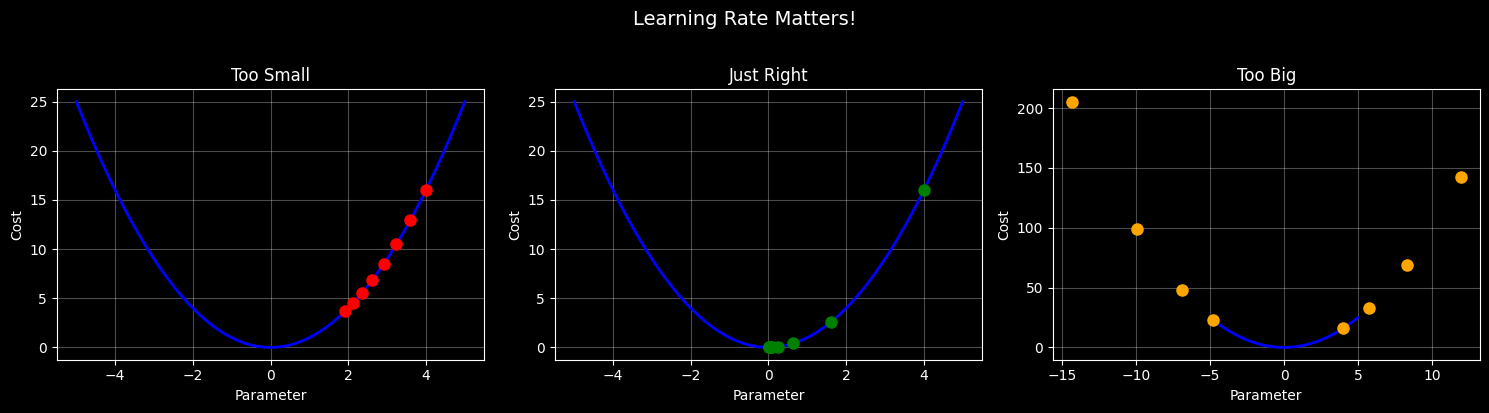

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.linspace(-5, 5, 100)
y = x**2

scenarios = [
    (0.05, 'Too Small', 'red'),
    (0.3, 'Just Right', 'green'),
    (1.1, 'Too Big', 'orange')
]

for idx, (lr, title, color) in enumerate(scenarios):
    ax = axes[idx]
    ax.plot(x, y, 'b-', linewidth=2)
    
    x_current = 4
    for i in range(8):
        ax.plot(x_current, x_current**2, 'o', color=color, markersize=8)
        gradient = 2 * x_current
        x_current = x_current - lr * gradient
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Parameter')
    ax.set_ylabel('Cost')
    ax.grid(True, alpha=0.3)

plt.suptitle('Learning Rate Matters!', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Summary / 总结

**English:**
- **Cost Function** = How wrong is my model? / 我的模型有多错？
- **Gradient Descent** = Walk down the hill to reduce cost / 走下山以减少代价
- **Learning Rate** = Step size / 步长大小

**中文：**
- **代价函数** = 我的模型有多错？
- **梯度下降** = 走下山以减少代价
- **学习率** = 步长大小

---

> **English:** Next: We will code this from scratch! You will see the model actually walk down the cost function.
> **中文：** 下一步：我们将从零写代码！你会看到模型真的在"走下山"。